<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning</b></center>

<center><b><h1>Lab - 6</b></center>    
<pre>    

# SVR

# Importing the libraries

In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Read World bank CSV

In [23]:
df = pd.read_csv("WorldBank.csv")


In [9]:
df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,India,IND,Export value index (2000 = 100),TX.VAL.MRCH.XD.WD,NaN,NaN,NaN,NaN,NaN,NaN,...,7.147485e+02,7.004085e+02,7.429281e+02,7.614417e+02,6.322694e+02,6.242250e+02,7.061028e+02,7.663608e+02,NaN,NaN
1,India,IND,Insurance and financial services (% of commerc...,TX.VAL.INSF.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,6.403614e+00,5.246771e+00,5.729495e+00,5.060904e+00,4.706801e+00,4.471147e+00,3.760466e+00,3.921611e+00,3.438072e+00,NaN
2,India,IND,"Merchandise imports by the reporting economy, ...",TM.VAL.MRCH.RS.ZS,4.983551,6.488050e+00,1.012461e+01,9.451370e+00,1.052948e+01,1.089112e+01,...,7.550664e-01,2.738416e-01,4.409538e-01,1.514439e+00,2.228351e+00,2.270593e+00,1.770314e+00,5.354193e-01,NaN,NaN
3,India,IND,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,1.708001e+01,1.519791e+01,1.686304e+01,2.200813e+01,...,3.741041e+00,4.048246e+00,3.895215e+00,4.458509e+00,5.758038e+00,6.505293e+00,6.137617e+00,4.156488e+00,4.248261e+00,NaN
4,India,IND,Share of tariff lines with international peaks...,TM.TAX.MRCH.IP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,8.434346e+00,8.641136e+00,8.576307e+00,NaN,5.802677e+00,7.707811e+00,8.288774e+00,9.111423e+00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,India,IND,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.002065e+00,1.312934e+00,1.516276e+00,1.695659e+00,2.092116e+00,1.937363e+00,1.506588e+00,1.552336e+00,1.760283e+00,NaN
1436,India,IND,"Net capital account (BoP, current US$)",BN.TRF.KOGT.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,6.791581e+07,-5.972328e+08,9.618297e+08,-7.433364e+07,3.706943e+07,1.368359e+08,3.731153e+07,-1.231007e+08,-1.155591e+09,NaN
1437,India,IND,"Travel services (% of service imports, BoP)",BM.GSR.TRVL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,1.761773e+01,1.544257e+01,1.475397e+01,1.799216e+01,1.795378e+01,1.707263e+01,1.686302e+01,1.716750e+01,1.755462e+01,NaN
1438,India,IND,Cereal production (metric tons),AG.PRD.CREL.MT,NaN,8.737650e+07,8.725755e+07,9.037301e+07,9.370600e+07,7.969950e+07,...,2.878600e+08,2.932900e+08,2.949095e+08,2.960100e+08,2.843330e+08,2.978500e+08,3.136100e+08,NaN,NaN,NaN


In [15]:
df.shape

(1440, 65)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 65 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    1440 non-null   object 
 1   Country Code    1440 non-null   object 
 2   Indicator Name  1440 non-null   object 
 3   Indicator Code  1440 non-null   object 
 4   1960            277 non-null    float64
 5   1961            315 non-null    float64
 6   1962            326 non-null    float64
 7   1963            328 non-null    float64
 8   1964            331 non-null    float64
 9   1965            337 non-null    float64
 10  1966            331 non-null    float64
 11  1967            338 non-null    float64
 12  1968            336 non-null    float64
 13  1969            344 non-null    float64
 14  1970            426 non-null    float64
 15  1971            514 non-null    float64
 16  1972            478 non-null    float64
 17  1973            484 non-null    f

# Perform conditional selection to find - Population ages 15-64 (% of total population)

In [27]:
result = df[df['Indicator Name'] == 'Population ages 15-64 (% of total population)']

In [29]:
result

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
9,India,IND,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,56.49748,56.177532,55.807455,55.461664,55.248939,55.211351,...,64.429404,64.805519,65.208489,65.59598,65.944164,66.274262,66.538187,66.766743,67.003811,NaN


# Divide the data into input and output

In [ ]:
# X = []

# for year in range(1960, 2021):
#     X.append(year)


In [31]:
x = np.arange(1960,2020).reshape(-1,1)

In [33]:
result.values

array([['India', 'IND', 'Population ages 15-64 (% of total population)',
        'SP.POP.1564.TO.ZS', 56.49748004, 56.17753236, 55.80745463,
        55.46166361, 55.24893881, 55.21135053, 55.09090078, 55.15534672,
        55.34507283, 55.57014408, 55.78194745, 55.85676846, 55.95268174,
        56.07247186, 56.23447551, 56.44405309, 56.49722595, 56.62068516,
        56.78900152, 56.9691436, 57.1425581, 57.18105454, 57.22630775,
        57.28875038, 57.39054366, 57.54142108, 57.55350984, 57.6545119,
        57.81875323, 58.01501187, 58.22990246, 58.37403848, 58.5472698,
        58.75605047, 59.012126, 59.31657719, 59.56507329, 59.8572303,
        60.18600058, 60.53971518, 60.90862046, 61.18898716, 61.4993847,
        61.83084479, 62.173897, 62.52276485, 62.80842981, 63.10261029,
        63.40924784, 63.74196691, 64.10821053, 64.429404, 64.80551944,
        65.20848906, 65.5959799, 65.94416405, 66.27426247, 66.53818711,
        66.7667425, 67.00381119, nan]], dtype=object)

In [37]:
y= result.values[0][4:-1].reshape(-1,1)

In [39]:
y

array([[56.49748004],
       [56.17753236],
       [55.80745463],
       [55.46166361],
       [55.24893881],
       [55.21135053],
       [55.09090078],
       [55.15534672],
       [55.34507283],
       [55.57014408],
       [55.78194745],
       [55.85676846],
       [55.95268174],
       [56.07247186],
       [56.23447551],
       [56.44405309],
       [56.49722595],
       [56.62068516],
       [56.78900152],
       [56.9691436],
       [57.1425581],
       [57.18105454],
       [57.22630775],
       [57.28875038],
       [57.39054366],
       [57.54142108],
       [57.55350984],
       [57.6545119],
       [57.81875323],
       [58.01501187],
       [58.22990246],
       [58.37403848],
       [58.5472698],
       [58.75605047],
       [59.012126],
       [59.31657719],
       [59.56507329],
       [59.8572303],
       [60.18600058],
       [60.53971518],
       [60.90862046],
       [61.18898716],
       [61.4993847],
       [61.83084479],
       [62.173897],
       [62.52276485]

# Plot scatter plot of Population ages 15-64 (% of total population)

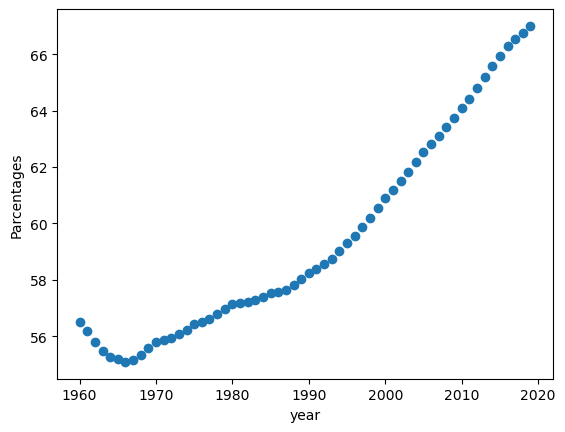

In [41]:
plt.scatter(x,y)
plt.xlabel("year")
plt.ylabel("Parcentages")
plt.show()

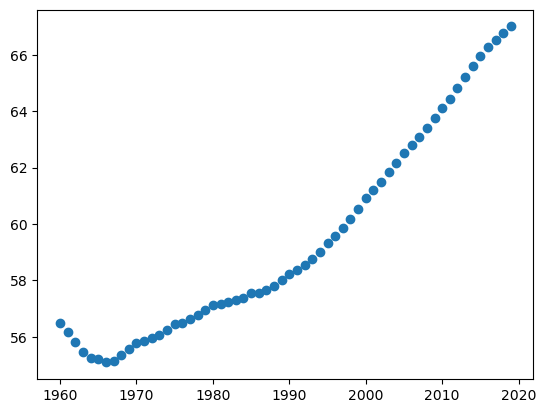

# Feature Scaling (Mandatory for SVR)**
SVR is highly sensitive to the range of data points. If we don't scale (normalize) the data, the model will fail to find the correct hyperplane.

In [43]:
from sklearn.preprocessing import StandardScaler

scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_scaled = scaler_x.fit_transform(x)
y_scaled = scaler_y.fit_transform(y)

print("Scaling completed")


Scaling completed


# Fitting SVR on Linear Kernel on dataset

In [45]:
from sklearn.svm import SVR

In [47]:
svr = SVR(kernel='linear')

In [49]:
svr.fit(x_scaled, y_scaled.ravel())

SVR(kernel='linear')

# Predict Values using Model

In [61]:
# use inverse_transform
y_pred_scaled = svr.predict(x_scaled)
y_pred_scaled

array([-1.67183895, -1.6161734 , -1.56050784, -1.50484228, -1.44917672,
       -1.39351116, -1.33784561, -1.28218005, -1.22651449, -1.17084893,
       -1.11518337, -1.05951782, -1.00385226, -0.9481867 , -0.89252114,
       -0.83685558, -0.78119003, -0.72552447, -0.66985891, -0.61419335,
       -0.55852779, -0.50286224, -0.44719668, -0.39153112, -0.33586556,
       -0.2802    , -0.22453444, -0.16886889, -0.11320333, -0.05753777,
       -0.00187221,  0.05379335,  0.1094589 ,  0.16512446,  0.22079002,
        0.27645558,  0.33212114,  0.38778669,  0.44345225,  0.49911781,
        0.55478337,  0.61044893,  0.66611448,  0.72178004,  0.7774456 ,
        0.83311116,  0.88877672,  0.94444228,  1.00010783,  1.05577339,
        1.11143895,  1.16710451,  1.22277007,  1.27843562,  1.33410118,
        1.38976674,  1.4454323 ,  1.50109786,  1.55676341,  1.61242897])

In [55]:
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))


In [59]:
print(y_pred[:10])


[[53.38449391]
 [53.58580857]
 [53.78712322]
 [53.98843788]
 [54.18975254]
 [54.3910672 ]
 [54.59238185]
 [54.79369651]
 [54.99501117]
 [55.19632582]]


# Predict the X_scaled using 3 Kernel

In [63]:
# above Steps Only - Kernel Change
svr = SVR(kernel='rbf')

In [65]:
svr.fit(x_scaled, y_scaled.ravel())

SVR()

In [67]:
y_pred_scaled1 = svr.predict(x_scaled)

In [69]:
y_pred1 = scaler_y.inverse_transform(y_pred_scaled1.reshape(-1,1))

In [71]:
print(y_pred1[:10])

[[56.13497486]
 [55.97146235]
 [55.82856335]
 [55.70825423]
 [55.61207123]
 [55.54106602]
 [55.49577833]
 [55.47622738]
 [55.48192233]
 [55.51189157]]


In [73]:
svr = SVR(kernel='poly')

In [75]:
svr.fit(x_scaled,y_scaled.ravel())

SVR(kernel='poly')

In [77]:
y_pred_scaled2 = svr.predict(x_scaled)

In [79]:
y_pred2 = scaler_y.inverse_transform(y_pred_scaled2.reshape(-1,1))

In [81]:
print(y_pred2[:10])

[[50.27541224]
 [51.14642777]
 [51.9584148 ]
 [52.71344452]
 [53.41358808]
 [54.06091668]
 [54.65750148]
 [55.20541366]
 [55.70672439]
 [56.16350485]]


# Visualising the  results

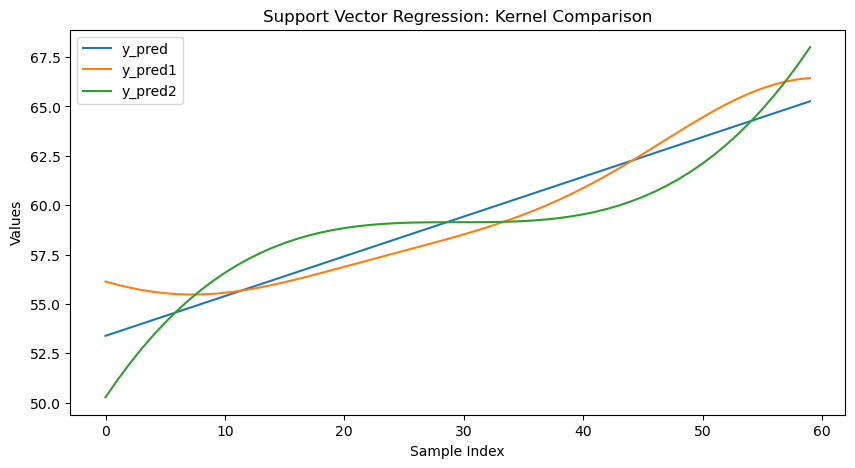

In [97]:
import matplotlib.pyplot as plt

# If result is a DataFrame column
y_actual = result.values.flatten()   # converts to 1D array

plt.figure(figsize=(10,5))

# Line plots
plt.plot(y_pred, label='y_pred')
plt.plot(y_pred1, label='y_pred1')
plt.plot(y_pred2, label='y_pred2')

# # Scatter plot
# plt.scatter(range(len(y_actual)), y_actual, color='red', label='Actual Result')

plt.xlabel("Sample Index")
plt.ylabel("Values")
plt.title("Support Vector Regression: Kernel Comparison")
plt.legend()
plt.show()


### **Student Activity : Prediction**
**Task:** Predict the value for the Year **2025** (or value 6.5 in the demo data). 
Remember: You must transform the input before predicting, and inverse transform the output.

The predicted value for input 2025 is: 66.47


# Extra
# Till now, we have not divided the dataset into training and testing sets.
# Please split the data into training and testing datasets and calculate the Residual Sum of Squares (RSS) for the model.